<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical - 10
Implement Backpropagation Neural Network and K-means using sklearn.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Part 1: Backprop NN on Iris ===
Test Accuracy: 0.9737

Classification report:
               precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        13
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9231    1.0000    0.9600        12

    accuracy                         0.9737        38
   macro avg     0.9744    0.9744    0.9733        38
weighted avg     0.9757    0.9737    0.9737        38



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Part 2: K-Means on Iris ===
Cluster centers :
 [[ 1.136  0.088  0.996  1.018]
 [-1.015  0.853 -1.305 -1.255]
 [-0.05  -0.883  0.348  0.282]]
Inertia: 139.820
Adjusted Rand Index: 0.6201
Silhouette Score   : 0.4599


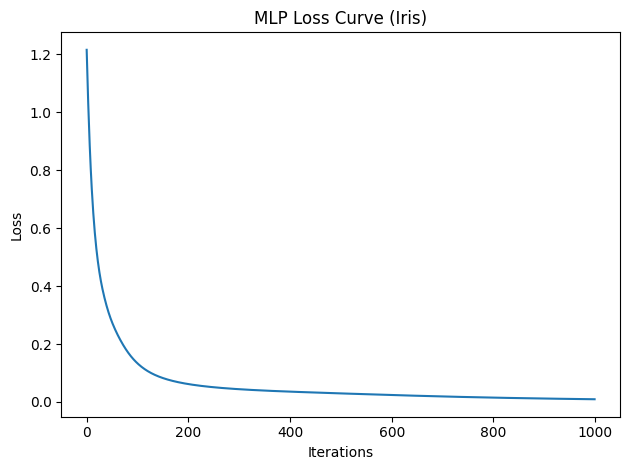

<Figure size 640x480 with 0 Axes>

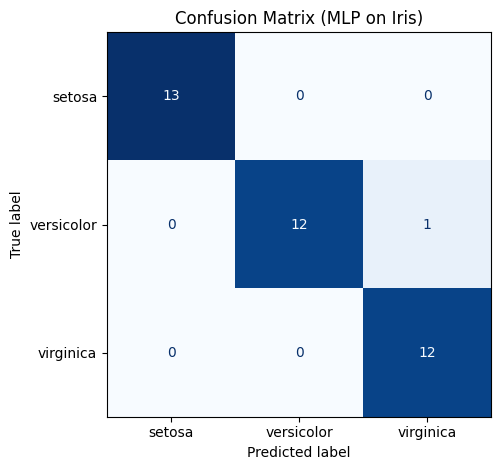

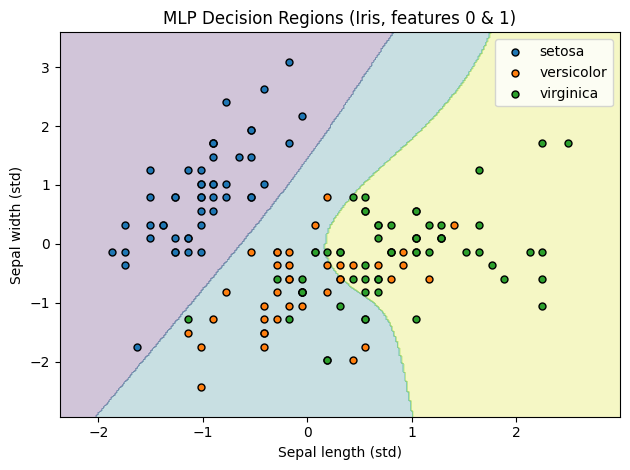

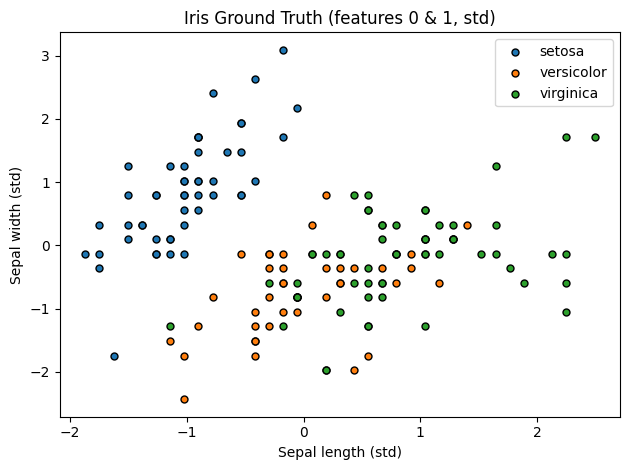

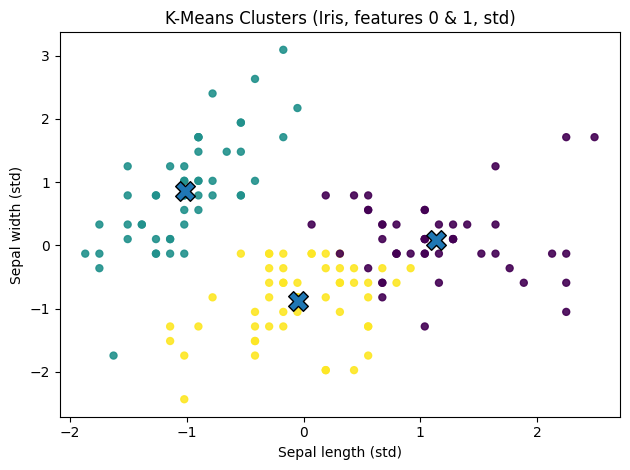

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import adjusted_rand_score, silhouette_score

iris = load_iris()
X = iris.data
y = iris.target
names = iris.target_names

# Backprop NN
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = MLPClassifier(hidden_layer_sizes=(8,), activation="tanh",
                    solver="adam", learning_rate_init=0.01,
                    max_iter=1000, random_state=7, tol=1e-6)

clf.fit(X_tr_s, y_tr)
y_pred = clf.predict(X_te_s)
acc = accuracy_score(y_te, y_pred)
print("\n=== Part 1: Backprop NN on Iris ===")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification report:\n", classification_report(y_te, y_pred, target_names=names, digits=4))

# Loss curve
plt.figure()
plt.plot(clf.loss_curve_)
plt.title("MLP Loss Curve (Iris)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.tight_layout()

# Confusion matrix
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=names, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (MLP on Iris)")
plt.tight_layout()

# Decision regions on first two features
feat_idx = (0, 1)
X2 = X[:, feat_idx]
scaler2 = StandardScaler()
X2_s = scaler2.fit_transform(X2)

clf2 = MLPClassifier(hidden_layer_sizes=(8,), activation="tanh",
                     solver="adam", learning_rate_init=0.01,
                     max_iter=1000, random_state=7, tol=1e-6)
clf2.fit(X2_s, y)

xx, yy = np.meshgrid(
    np.linspace(X2_s[:, 0].min() - 0.5, X2_s[:, 0].max() + 0.5, 300),
    np.linspace(X2_s[:, 1].min() - 0.5, X2_s[:, 1].max() + 0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = clf2.predict(grid).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, zz, alpha=0.25)
for lab in np.unique(y):
    pts = X2_s[y == lab]
    plt.scatter(pts[:, 0], pts[:, 1], s=25, edgecolor="k", label=names[lab])
plt.title("MLP Decision Regions (Iris, features 0 & 1)")
plt.xlabel("Sepal length (std)")
plt.ylabel("Sepal width (std)")
plt.legend()
plt.tight_layout()

# K-Means
X_s_all = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=7)
labels = kmeans.fit_predict(X_s_all)
ari = adjusted_rand_score(y, labels)
sil = silhouette_score(X_s_all, labels)

print("\n=== Part 2: K-Means on Iris ===")
print("Cluster centers :\n", np.round(kmeans.cluster_centers_, 3))
print(f"Inertia: {kmeans.inertia_:.3f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score   : {sil:.4f}")

# True labels
X2_all = X_s_all[:, feat_idx]
plt.figure()
for lab in np.unique(y):
    pts = X2_all[y == lab]
    plt.scatter(pts[:, 0], pts[:, 1], s=25, edgecolor="k", label=names[lab])
plt.title("Iris Ground Truth (features 0 & 1, std)")
plt.xlabel("Sepal length (std)")
plt.ylabel("Sepal width (std)")
plt.legend()
plt.tight_layout()

# K-Means clusters
plt.figure()
plt.scatter(X2_all[:, 0], X2_all[:, 1], c=labels, s=25, alpha=0.9)
centers2 = kmeans.cluster_centers_[:, feat_idx]
plt.scatter(centers2[:, 0], centers2[:, 1], marker="X", s=200, edgecolor="k")
plt.title("K-Means Clusters (Iris, features 0 & 1, std)")
plt.xlabel("Sepal length (std)")
plt.ylabel("Sepal width (std)")
plt.tight_layout()

plt.show()